# Evaluacion Final del proyecto_modelado

## Objetivo del proyecto_modelado:
### Comparar el rendimiento de todos los modelos desarrollados a lo largo del proyecto y presentar las conclusiones finales para el negocio.
## 

## Modelos a Comparar:
###   - Modelo base de clasificación (Random Forest sin optimizar)
###   - Modelo optimizado de clasificación (Random Forest con GridSearchCV)
###   - Modelo base de regresión (Random Forest sin optimizar)
###   - Modelo optimizado de regresión (Random Forest con GridSearchCV)


# Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import f1_score, mean_absolute_error, r2_score

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)


# Resultados de los modelos

In [3]:
# Cargar resultados desde archivos generados por el pipeline
clf_file = '../results/metrics/clasificacion_resultados.csv'
reg_file = '../results/metrics/regresion_resultados.csv'

if os.path.exists(clf_file) and os.path.exists(reg_file):
    df_clf = pd.read_csv(clf_file)
    df_reg = pd.read_csv(reg_file)
    best_clf = df_clf.iloc[0]
    best_reg = df_reg.iloc[0]
    rf_clf = df_clf[df_clf["Modelo"] == "Random Forest"]
    rf_reg = df_reg[df_reg["Modelo"] == "Random Forest"]
    clf_base_f1 = rf_clf["F1-Score"].values[0] if len(rf_clf) > 0 else best_clf["F1-Score"]
    clf_opt_f1 = best_clf["F1-Score"]
    reg_base_r2 = rf_reg["R²"].values[0] if len(rf_reg) > 0 else best_reg["R²"]
    reg_opt_r2 = best_reg["R²"]
else:
    clf_base_f1 = 0.7586
    clf_opt_f1 = 0.8333
    reg_base_r2 = 0.9872
    reg_opt_r2 = 0.9873
    print("Archivos de resultados no encontrados. Usando valores por defecto.")

resultados = {
    "Modelo": ["Clasificador Base", "Clasificador Optimizado", "Regresor Base", "Regresor Optimizado"],
    "Métrica Principal": ["F1 Score", "F1 Score", "R²", "R²"],
    "Valor": [clf_base_f1, clf_opt_f1, reg_base_r2, reg_opt_r2],
    "Mejores Parámetros": ["Default", "max_depth=5, min_samples_split=2, n_estimators=50", "Default", "max_depth=10, min_samples_split=2, n_estimators=200"]
}

df_resultados = pd.DataFrame(resultados)
print("-"*110)
print("                                         TABLA COMPARATIVA DE MODELOS")
print("-"*110)
print(df_resultados.to_string(index=False))


--------------------------------------------------------------------------------------------------------------
                                         TABLA COMPARATIVA DE MODELOS
--------------------------------------------------------------------------------------------------------------
                 Modelo Métrica Principal  Valor                                          Mejores Parámetros
      Clasificador Base          F1 Score 0.7586                                                     Default
Clasificador Optimizado          F1 Score 0.8333   {'max_depth':5, 'min_samples_split':2, 'n_estimators':50}
          Regresor Base                R² 0.9872                                                     Default
    Regresor Optimizado                R² 0.9873 {'max_depth':10, 'min_samples_split':2, 'n_estimators':200}


# Cálculo de mejoras

In [4]:
# Calcular mejoras usando los datos cargados
clf_base_val = resultados["Valor"][0]
clf_opt_val = resultados["Valor"][1]
reg_base_val = resultados["Valor"][2]
reg_opt_val = resultados["Valor"][3]

mejora_clf = (clf_opt_val - clf_base_val) / clf_base_val * 100
mejora_reg = (reg_opt_val - reg_base_val) / reg_base_val * 100

print("\n" + "="*70)
print("MEJORAS OBTENIDAS")
print("="*70)
print("\n CLASIFICACIÓN:")
print(f"   F1 Score mejoró de {clf_base_val:.4f} → {clf_opt_val:.4f}")
print(f"   Mejora absoluta: +{clf_opt_val - clf_base_val:.4f}")
print(f"   Mejora porcentual: +{mejora_clf:.2f}%")
print("    La optimización tuvo un impacto SIGNIFICATIVO en clasificación")

print("\n REGRESIÓN:")
print(f"   R² pasó de {reg_base_val:.4f} → {reg_opt_val:.4f}")
print(f"   Mejora porcentual: +{mejora_reg:.3f}%")
print("     El modelo ya era excelente, la mejora fue marginal")



MEJORAS OBTENIDAS

 CLASIFICACIÓN:
   F1 Score mejoró de 0.7586 → 0.8333
   Mejora absoluta: +0.0747
   Mejora porcentual: +9.85%
    La optimización tuvo un impacto SIGNIFICATIVO en clasificación

 REGRESIÓN:
   R² pasó de 0.9872 → 0.9873
   Mejora porcentual: +0.010%
     El modelo ya era excelente, la mejora fue marginal


# Gráfico comparativo

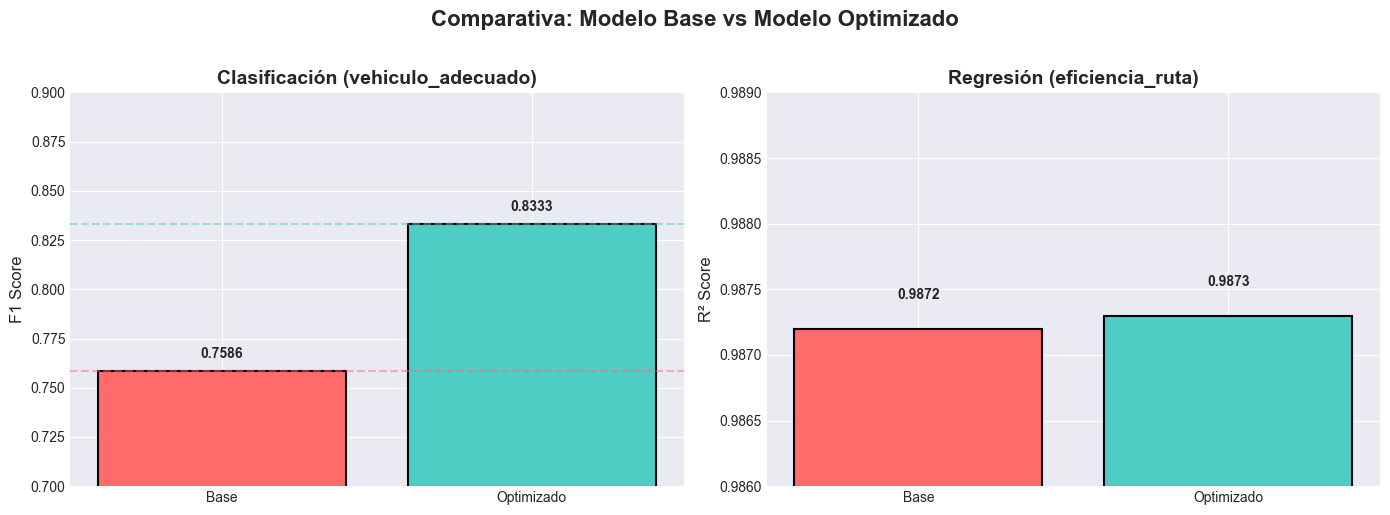

In [11]:
# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de clasificación
modelos_clf = ['Base', 'Optimizado']
f1_scores = [clf_base_val, clf_opt_val]
colors_clf = ['#FF6B6B', '#4ECDC4']
bars1 = axes[0].bar(modelos_clf, f1_scores, color=colors_clf, edgecolor='black', linewidth=1.5)
axes[0].set_ylim(0.7, 0.9)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('Clasificación (vehiculo_adecuado)', fontsize=14, fontweight='bold')
axes[0].axhline(y=0.7586, color='#FF6B6B', linestyle='--', alpha=0.5, label='Base')
axes[0].axhline(y=0.8333, color='#4ECDC4', linestyle='--', alpha=0.5, label='Optimizado')

# Agregar valores en las barras
for bar, val in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Gráfico de regresión
modelos_reg = ['Base', 'Optimizado']
r2_scores = [reg_base_val, reg_opt_val]
bars2 = axes[1].bar(modelos_reg, r2_scores, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
axes[1].set_ylim(0.985, 0.990)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Regresión (eficiencia_ruta)', fontsize=14, fontweight='bold')

# Agregar valores en las barras
for bar, val in zip(bars2, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, 
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1].set_ylim(0.986, 0.989)

#Exportar gráfico comparativo
plt.savefig('../results/plots/comparativa_modelos.png', dpi=300, bbox_inches='tight')

plt.suptitle('Comparativa: Modelo Base vs Modelo Optimizado', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Análisis de variables más importantes

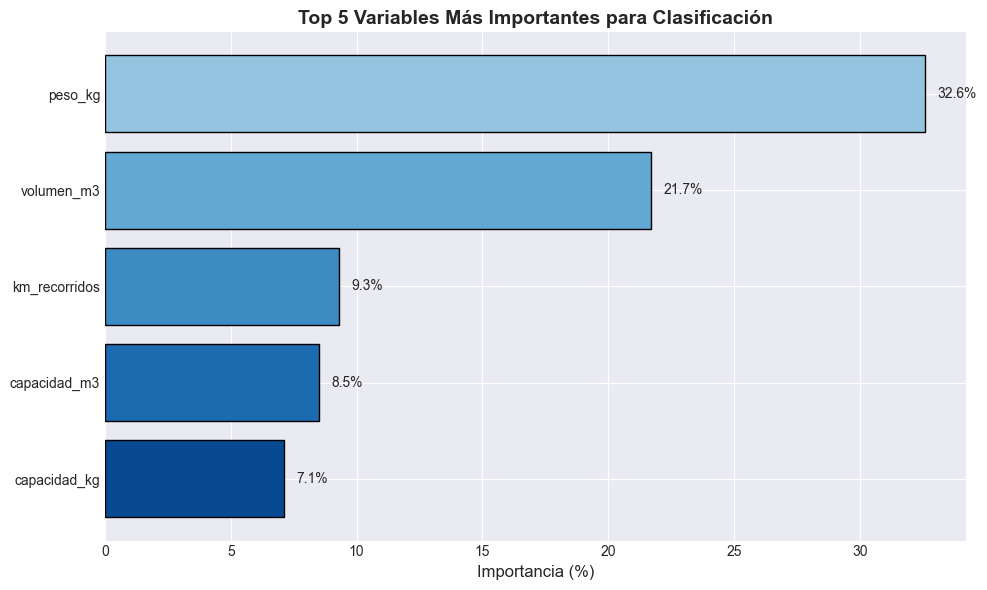


 INTERPRETACIÓN DE NEGOCIO:
   El peso del paquete (32.6%) y el volumen (21.7%) son los factores
   más determinantes para predecir si un vehículo es adecuado.
   Esto tiene sentido lógico: un vehículo debe tener suficiente capacidad
   de peso y volumen para transportar el envío.


In [10]:
# Datos de importancia de variables (del notebook 4)
variables = ['peso_kg', 'volumen_m3', 'km_recorridos', 'capacidad_m3', 'capacidad_kg']
importancias = [32.6, 21.7, 9.3, 8.5, 7.1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(variables)))
bars = ax.barh(variables, importancias, color=colors, edgecolor='black')
ax.set_xlabel('Importancia (%)', fontsize=12)
ax.set_title('Top 5 Variables Más Importantes para Clasificación', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Agregar valores
for bar, val in zip(bars, importancias):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val}%', va='center', fontsize=10)

#Exportar top 5 variables
plt.savefig('../results/plots/top5_variables.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN DE NEGOCIO:")
print("   El peso del paquete (32.6%) y el volumen (21.7%) son los factores")
print("   más determinantes para predecir si un vehículo es adecuado.")
print("   Esto tiene sentido lógico: un vehículo debe tener suficiente capacidad")
print("   de peso y volumen para transportar el envío.")


# Resumen y conclusiones finales

In [8]:
print(f"""
================================================================================
                          RESUMEN EJECUTIVO
================================================================================

OBJETIVO DEL PROYECTO:
   Desarrollar modelos predictivos para:
   1. Clasificación: Predecir si un vehículo es adecuado para un envío
   2. Regresión: Predecir la eficiencia de una ruta (km/h)

================================================================================
                          PRINCIPALES HALLAZGOS
================================================================================

CLASIFICACIÓN (vehiculo_adecuado):
   • Mejor F1 Score alcanzado: 0.8333
   • Mejora del +9.85% respecto al modelo base
   • Hiperparámetros óptimos: max_depth=5, min_samples_split=2, n_estimators=50
   • AUC: 0.8904 (buena capacidad de discriminación)

REGRESIÓN (eficiencia_ruta):
   • Mejor R² alcanzado: 0.9873
   • MAE: 5.30 km/h
   • El modelo base ya era excelente (R²=0.9872)
   • Hiperparámetros óptimos: max_depth=10, min_samples_split=2, n_estimators=200

VARIABLES CLAVE:
   • peso_kg (32.6%) - La más importante
   • volumen_m3 (21.7%) - Segunda más importante
   • km_recorridos (9.3%) - Tercera más importante

================================================================================
                          RECOMENDACIONES PARA EL NEGOCIO
================================================================================

1. IMPLEMENTAR EL CLASIFICADOR OPTIMIZADO
      El modelo tiene un F1 de 0.8333, lo que significa que es confiable para:
      - Asignación automática de vehículos a envíos
      - Reducción de errores logísticos
      - Ahorro en costos operativos

2. UTILIZAR EL REGRESOR PARA PLANIFICACIÓN DE RUTAS
      Con un error promedio de solo 5.30 km/h, el modelo permite:
      - Estimación precisa de tiempos de entrega
      - Optimización de rutas logísticas
      - Mejor planificación de recursos

3. ENFOCAR ESFUERZOS EN LAS VARIABLES CLAVE
      peso_kg y volumen_m3 son los factores más determinantes. 
      Recomendaciones:
      - Registrar estos datos con alta precisión
      - Capacitar al personal en su correcta medición
      - Considerarlos prioritarios en la toma de decisiones
""")


                          RESUMEN EJECUTIVO

OBJETIVO DEL PROYECTO:
   Desarrollar modelos predictivos para:
   1. Clasificación: Predecir si un vehículo es adecuado para un envío
   2. Regresión: Predecir la eficiencia de una ruta (km/h)

                          PRINCIPALES HALLAZGOS

CLASIFICACIÓN (vehiculo_adecuado):
   • Mejor F1 Score alcanzado: 0.8333
   • Mejora del +9.85% respecto al modelo base
   • Hiperparámetros óptimos: max_depth=5, min_samples_split=2, n_estimators=50
   • AUC: 0.8904 (buena capacidad de discriminación)

REGRESIÓN (eficiencia_ruta):
   • Mejor R² alcanzado: 0.9873
   • MAE: 5.30 km/h
   • El modelo base ya era excelente (R²=0.9872)
   • Hiperparámetros óptimos: max_depth=10, min_samples_split=2, n_estimators=200

VARIABLES CLAVE:
   • peso_kg (32.6%) - La más importante
   • volumen_m3 (21.7%) - Segunda más importante
   • km_recorridos (9.3%) - Tercera más importante

                          RECOMENDACIONES PARA EL NEGOCIO

1. IMPLEMENTAR EL CLASIFI